# Testing energy metabolism model

Nathaniel Linden (UCSD MAE) - Oct  2024

In [6]:
import jax
import numpy as np
import jax.numpy as jnp
import equinox as eqx
import diffrax as dfrx
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import sys, json
import met_brewer as mb
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# add odes code
sys.path.append('../models/')
from metabolism_diffrax import *
from metabolism_Coccimiglio_et_al_diffrax import *

# set plot style and import helper functions
plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True
colors = mb.met_brew(name="Veronese", n=7)

# plotting helper functions
# add odes code
sys.path.append('../')
from plotting_helper_funcs import *

# set Jax to use 64-bit precision and CPU
jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')

save_path = '../../../results/metab_testing/'


### Set-up the metabolism model
- Set up RHS from the `../odes/metabolism_diffrax.py` file
- Set up initial conditions and parameters from the `../odes/metabolism_params.json` file

In [7]:
# ODE for metabolism model in diffrax
rhs_Cocci = dfrx.ODETerm(metabolism_Cocci())
rhs = dfrx.ODETerm(metabolism())

# define the parameters
metab_params_file = '../models/metabolism_params.json'
with open(metab_params_file, 'r') as file:
           metab_params = json.load(file)

metab_params_file_Cocci = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file_Cocci, 'r') as file:
           metab_params_Cocci = json.load(file)

metab_params_basal = jnp.array(list(metab_params['metab_params_basal'].values()))
metab_params_stress = jnp.array(list(metab_params['metab_params_stress'].values()))
metab_params_basal_Cocci = jnp.array(list(metab_params_Cocci['metab_params_basal'].values()))
metab_params_stress_Cocci = jnp.array(list(metab_params_Cocci['metab_params_stress'].values()))

# inital conditions
y0 = jnp.array([2e-5, 1.3e-2, 8.2]) # AMP, ADP, ATP (mM) # TODO: check units
y0_Cocci = jnp.array([2e-5, 1.3e-2, 8.2, 22.1])

times = jnp.arange(0, 360, 0.25) # seconds
t0, t1 = times[0], times[-1]

# solver info
solver=dfrx.Kvaerno5()
stepsize_controller = dfrx.PIDController(rtol=1e-8, atol=1e-8)
dt0 = 1e-8 # initial time step
saveat=dfrx.SaveAt(ts=times)

# simulation
sol = dfrx.diffeqsolve(rhs, solver, t0, t1, dt0, y0, args = metab_params_basal, saveat=saveat, stepsize_controller=stepsize_controller)
sol_Cocci = dfrx.diffeqsolve(rhs_Cocci, solver, t0, t1, dt0, y0_Cocci, args = metab_params_basal_Cocci, saveat=saveat, stepsize_controller=stepsize_controller)
y0_new = sol.ys[-1,:] # use the final state as the initial condition for the next simulation
y0_new_Cocci = sol_Cocci.ys[-1,:] # use the final state as the initial condition for the next simulation

### First, explore the initial transients 

##### model without Creatine Kinase (metabolism_diffrax.py)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/582915851.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_path + 'metab_basal.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/582915851.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_path + 'metab_basal_ratios.pdf', bbox_inches='tight', transparent=True)


[650.          96.95759381  52.75251062 ...  21.03122649  21.03122649
  21.03122649]


/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


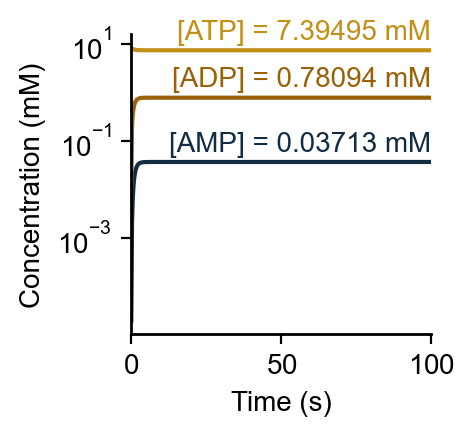

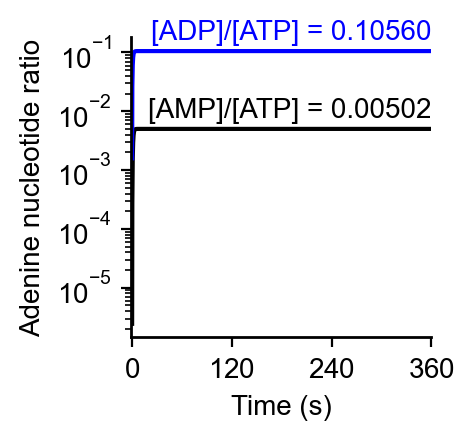

In [8]:
# Raw [AMP], [ADP], [ATP] values
# plot
fig, ax = get_sized_fig_ax(width=1.5, height=1.5)
amp_ln, = ax.plot(sol.ts, sol.ys[:,0], label='AMP', color=colors[2])
adp_ln, = ax.plot(sol.ts, sol.ys[:,1], label='ADP', color=colors[3])
atp_ln, = ax.plot(sol.ts, sol.ys[:,2], label='ATP', color=colors[4])
ax.set_yscale('log')

# add labels
# Add text labels at the final x values
buffer = 0
yshift = 1.25
plt.text(100 + buffer, sol.ys[-1,0] * yshift, f'[AMP] = {sol.ys[-1,0]:.5f} mM', 
         verticalalignment='bottom', horizontalalignment='right', color=amp_ln.get_color(), fontsize=10)
plt.text(100 + buffer, sol.ys[-1,1] * yshift, f'[ADP] = {sol.ys[-1,1]:.5f} mM', 
         verticalalignment='bottom', horizontalalignment='right', color=adp_ln.get_color(), fontsize=10)
plt.text(100 + buffer, sol.ys[-1,2] * yshift, f'[ATP] = {sol.ys[-1,2]:.5f} mM', 
         verticalalignment='bottom', horizontalalignment='right', color=atp_ln.get_color(), fontsize=10)
ax.set_xlim([-1, times[-1] + 0])
ax.set_xticks([0, 50, 100])
ax.set_xlim([0, 1e2])

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Concentration (mM)', fontsize=10)

fig.savefig(save_path + 'metab_basal.pdf', bbox_inches='tight', transparent=True)

# Ratios of [AMP]/[ATP] and [ADP]/[ATP]
# plot
fig, ax = get_sized_fig_ax(width=1.5, height=1.5)
amp_atp_ln, = ax.plot(sol.ts, sol.ys[:,0]/sol.ys[:,2], label='AMP:ATP', color='black')
adp_atp_ln, = ax.plot(sol.ts, sol.ys[:,1]/sol.ys[:,2], label='ADP:ATP', color='blue')

print(sol.ys[:,1]/sol.ys[:,0])

# add labels
# Add text labels at the final x values
buffer = 0
yshift = 1.25
plt.text(sol.ts[-1] + buffer, (sol.ys[-1,0]/sol.ys[-1,2]) * (yshift+0.01), f'[AMP]/[ATP] = {sol.ys[-1,0]/sol.ys[-1,2]:.5f}', 
         verticalalignment='bottom', horizontalalignment='right', color=amp_atp_ln.get_color(), fontsize=10)
plt.text(sol.ts[-1] + buffer, (sol.ys[-1,1]/sol.ys[-1,2]) * yshift, f'[ADP]/[ATP] = {sol.ys[-1,1]/sol.ys[-1,2]:.5f}', 
         verticalalignment='bottom',  horizontalalignment='right', color=adp_atp_ln.get_color(), fontsize=10)

ax.set_xlim([-1, times[-1] + 0])
ax.set_xticks([0, 120, 240, 360])
ax.set_yscale('log')

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Adenine nucleotide ratio', fontsize=10)

y0_new = sol.ys[-1,:] # use the final state as the initial condition for the next simulation

fig.savefig(save_path + 'metab_basal_ratios.pdf', bbox_inches='tight', transparent=True)

#### model with creatine kinase (metabolism_diffrax_Coccimiglio.py)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/3928600998.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_path + 'metab_basal_Cocci.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/3928600998.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_path + 'metab_basal_ratios_Cocci.pdf', bbox_inches='tight', transparent=True)


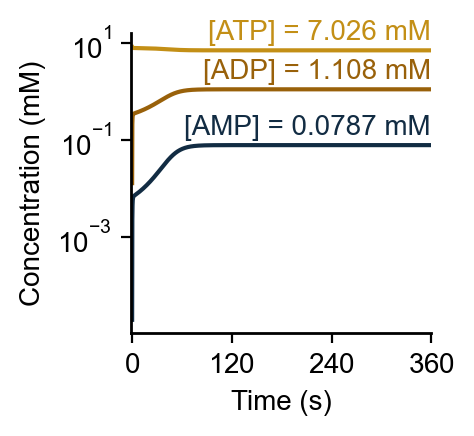

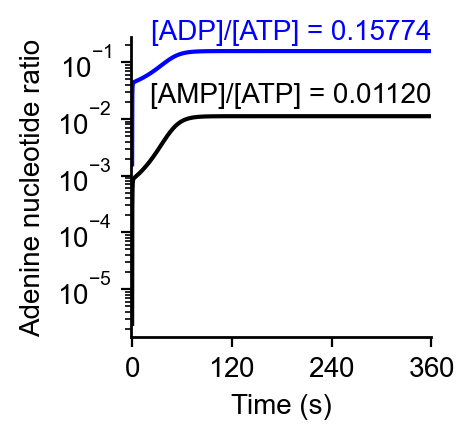

In [9]:
# plot
fig, ax = get_sized_fig_ax(width=1.5, height=1.5)
amp_ln, = ax.plot(sol_Cocci.ts, sol_Cocci.ys[:,0], label='AMP', color=colors[2])
adp_ln, = ax.plot(sol_Cocci.ts, sol_Cocci.ys[:,1], label='ADP', color=colors[3])
atp_ln, = ax.plot(sol_Cocci.ts, sol_Cocci.ys[:,2], label='ATP', color=colors[4])
ax.set_yscale('log')

# add labels
# Add text labels at the final x values
buffer = 0
yshift = 1.25
plt.text(sol_Cocci.ts[-1] + buffer, sol_Cocci.ys[-1,0] * yshift, f'[AMP] = {sol_Cocci.ys[-1,0]:.4f} mM', 
         verticalalignment='bottom', horizontalalignment='right', color=amp_ln.get_color(), fontsize=10)
plt.text(sol_Cocci.ts[-1] + buffer, sol_Cocci.ys[-1,1] * yshift, f'[ADP] = {sol_Cocci.ys[-1,1]:.3f} mM', 
         verticalalignment='bottom', horizontalalignment='right', color=adp_ln.get_color(), fontsize=10)
plt.text(sol_Cocci.ts[-1] + buffer, sol_Cocci.ys[-1,2] * yshift, f'[ATP] = {sol_Cocci.ys[-1,2]:.3f} mM', 
         verticalalignment='bottom', horizontalalignment='right', color=atp_ln.get_color(), fontsize=10)
ax.set_xlim([-1, times[-1] + 0])
ax.set_xticks([0, 120, 240, 360])

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Concentration (mM)', fontsize=10)

fig.savefig(save_path + 'metab_basal_Cocci.pdf', bbox_inches='tight', transparent=True)

# plot
fig, ax = get_sized_fig_ax(width=1.5, height=1.5)
amp_atp_ln, = ax.plot(sol_Cocci.ts, sol_Cocci.ys[:,0]/sol_Cocci.ys[:,2], label='AMP:ATP', color='black')
adp_atp_ln, = ax.plot(sol_Cocci.ts, sol_Cocci.ys[:,1]/sol_Cocci.ys[:,2], label='ADP:ATP', color='blue')
# adp_atp_ln, = ax.plot(sol_Cocci.ts, sol_Cocci.ys[:,1]/sol_Cocci.ys[:,0], label='ADP:ATP', color='green')

# add labels
# Add text labels at the final x values
buffer = 0
yshift =1.25
plt.text(sol_Cocci.ts[-1] + buffer, (sol_Cocci.ys[-1,0]/sol_Cocci.ys[-1,2]) * (yshift+0.1), f'[AMP]/[ATP] = {sol_Cocci.ys[-1,0]/sol_Cocci.ys[-1,2]:.5f}', 
         verticalalignment='bottom', horizontalalignment='right', color=amp_atp_ln.get_color(), fontsize=10)
plt.text(sol_Cocci.ts[-1] + buffer, (sol_Cocci.ys[-1,1]/sol_Cocci.ys[-1,2]) * yshift, f'[ADP]/[ATP] = {sol_Cocci.ys[-1,1]/sol_Cocci.ys[-1,2]:.5f}', 
         verticalalignment='bottom',  horizontalalignment='right', color=adp_atp_ln.get_color(), fontsize=10)

ax.set_xlim([-1, times[-1] + 0])
ax.set_xticks([0, 120, 240, 360])

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Adenine nucleotide ratio', fontsize=10)
ax.set_yscale('log')

fig.savefig(save_path + 'metab_basal_ratios_Cocci.pdf', bbox_inches='tight', transparent=True)

#### Now, perturb the glyocolysis rate and observe the response
- Use the SS from the previous simulation as the initial conditions
- Set the glycolysis rate to a new value that varies over some range

/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research/Project_3_AMPK/src/ampk_models/test_models_and_mass_conservation/../plotting_helper_funcs.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research/Project_3_AMPK/src/ampk_models/test_models_and_mass_conservation/../plotting_helper_funcs.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(filename, dpi="figure", bbox_inches=bbox, transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/2366033942.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_amp.savefig(save_path + 'metab_stress_amp.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp

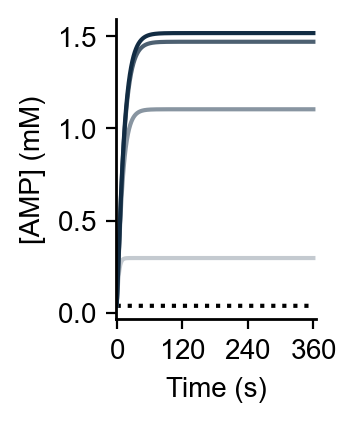

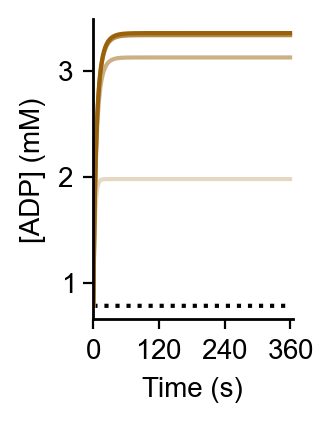

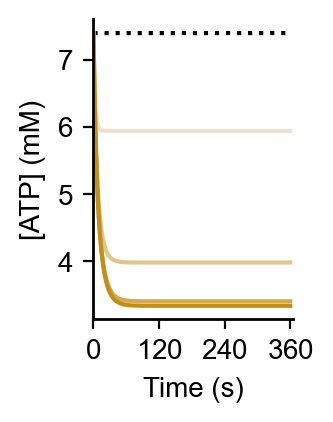

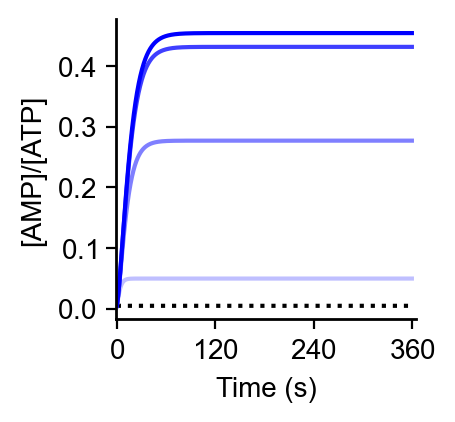

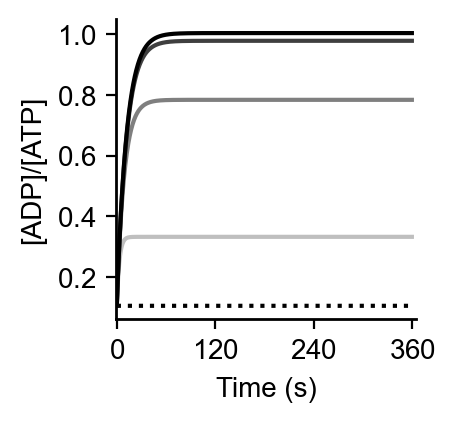

In [10]:
kGlys = jnp.array([0.5, 5e-2, 5e-3, 5e-4, 5e-5]) #, 5.0, 50.0])
sols = {}

for kGly in kGlys:
    metab_params_test = metab_params_basal.copy()
    metab_params_test = metab_params_test.at[0].set(kGly)

    sols[str(kGly)] = dfrx.diffeqsolve(rhs, solver, t0, t1, dt0, y0_new, args = metab_params_test, saveat=saveat, stepsize_controller=stepsize_controller)

cmap_amp = LinearSegmentedColormap.from_list("custom_cmap_amp", ["white", colors[2]])
amp_cols = cmap_amp(np.linspace(0, 1, len(kGlys)))
cmap_adp = LinearSegmentedColormap.from_list("custom_cmap_adp", ["white", colors[3]])
adp_cols = cmap_adp(np.linspace(0, 1, len(kGlys)))
cmap_atp = LinearSegmentedColormap.from_list("custom_cmap_atp", ["white", colors[4]])
atp_cols = cmap_atp(np.linspace(0, 1, len(kGlys)))

cmap_amp_atp = LinearSegmentedColormap.from_list("custom_cmap_amp_atp", ["white", 'blue'])
amp_atp_cols = cmap_amp_atp(np.linspace(0, 1, len(kGlys)))
cmap_adp_atp = LinearSegmentedColormap.from_list("custom_cmap_adp_atp", ["white", 'black'])
adp_atp_cols = cmap_adp_atp(np.linspace(0, 1, len(kGlys)))

# plot
fig_amp, ax_amp = get_sized_fig_ax(width=1.0, height=1.5)
fig_adp, ax_adp = get_sized_fig_ax(width=1.0, height=1.5)
fig_atp, ax_atp = get_sized_fig_ax(width=1.0, height=1.5)

fig_amp_atp, ax_amp_atp = get_sized_fig_ax(width=1.5, height=1.5)
fig_adp_atp, ax_adp_atp = get_sized_fig_ax(width=1.5, height=1.5)

for i, key in enumerate(sols.keys()):
    if key == '0.5':
        lstyle = ':'
        amp_col = 'black'
        adp_col = 'black'
        atp_col = 'black'
        amp_atp_col = 'black'
        adp_atp_col = 'black'
    else:
        lstyle = '-'
        amp_col = amp_cols[i]
        adp_col = adp_cols[ i]
        atp_col = atp_cols[ i]
        amp_atp_col = amp_atp_cols[ i]
        adp_atp_col = adp_atp_cols[ i]

    ax_amp.plot(sols[key].ts, sols[key].ys[:,0], label=key, color=amp_col, linestyle = lstyle)
    ax_adp.plot(sols[key].ts, sols[key].ys[:,1], label=key, color=adp_col, linestyle = lstyle)
    ax_atp.plot(sols[key].ts, sols[key].ys[:,2], label=key, color=atp_col, linestyle = lstyle)

    ax_amp_atp.plot(sols[key].ts, sols[key].ys[:,0]/sols[key].ys[:,2], label=key, color=amp_atp_col, linestyle = lstyle)
    ax_adp_atp.plot(sols[key].ts, sols[key].ys[:,1]/sols[key].ys[:,2], label=key, color=adp_atp_col, linestyle = lstyle)
    


for ax in [ax_amp, ax_adp, ax_atp, ax_amp_atp, ax_adp_atp]:
    # ax.set_yscale('log')
    ax.set_xlim([-1, times[-1] + 5])
    ax.set_xticks([0, 120, 240, 360])
    ax.set_xlabel('Time (s)', fontsize=10)

ax_amp.set_ylabel('[AMP] (mM)', fontsize=10)
ax_adp.set_ylabel('[ADP] (mM)', fontsize=10)
ax_atp.set_ylabel('[ATP] (mM)', fontsize=10)
ax_amp_atp.set_ylabel('[AMP]/[ATP]', fontsize=10)
ax_adp_atp.set_ylabel('[ADP]/[ATP]', fontsize=10)

leg = ax_adp_atp.legend([r'Basal $(k_{Gly} = 0.5)$', r'1e-1 $\cdot k_{Gly}$', 
                         r'1e-2 $\cdot k_{Gly}$', r'1e-3 $\cdot k_{Gly}$', 
                         r'1e-4 $\cdot k_{Gly}$'], fontsize=8, bbox_to_anchor = (1.5, 1.5, 1.5, 1.5), ncol=3)
export_legend(leg, save_path + 'metab_stress_legend.pdf')
leg.remove()

fig_amp.savefig(save_path + 'metab_stress_amp.pdf', bbox_inches='tight', transparent=True)
fig_adp.savefig(save_path + 'metab_stress_adp.pdf', bbox_inches='tight', transparent=True)
fig_atp.savefig(save_path + 'metab_stress_atp.pdf', bbox_inches='tight', transparent=True)
fig_amp_atp.savefig(save_path + 'metab_stress_amp_atp.pdf', bbox_inches='tight', transparent=True)
fig_adp_atp.savefig(save_path + 'metab_stress_adp_atp.pdf', bbox_inches='tight', transparent=True)




/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/961800633.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['5e-2', '5e-3', '5e-4', '5e-5'], fontsize=8, rotation=0)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/961800633.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['1e3', '1e4'], fontsize=8, rotation=0)


Text(0, 0.5, 'Change in ratio (%)')

/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


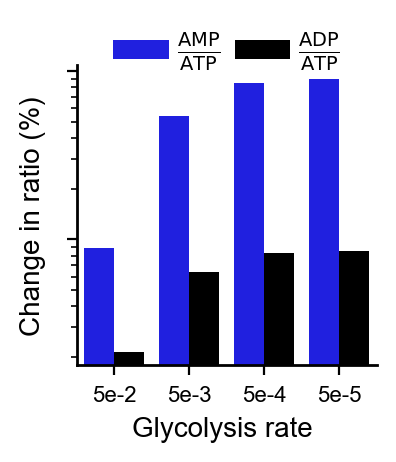

In [11]:
# plot a bar chart of the change in [AMP]/[ATP] and [ADP]/[ATP] ratios
baseline = (np.array(y0_new[0]/y0_new[2]), np.array(y0_new[1]/y0_new[2]))
ratios = {}
for key in sols.keys():
    if key == '0.5':
        pass
    else:
        ratios[key] = {'AMP_ATP':100*(np.array(sols[key].ys[-1,0]/sols[key].ys[-1,2]) - baseline[0])/baseline[0], 
                       'ADP_ATP':100*(np.array(sols[key].ys[-1,1]/sols[key].ys[-1,2]) - baseline[1])/baseline[1]}

dat = pd.DataFrame(ratios).reset_index().melt(id_vars='index', var_name='Ratio', value_name='Change (%)')

fig, ax = get_sized_fig_ax(width=1.5, height=1.5)
sns.barplot(data=dat, x='Ratio', y='Change (%)', hue='index', palette=['blue', 'black'], ax = ax)
ax.set_yscale('log')
# legend
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), fontsize=10, 
                   ncols=2,columnspacing=0.5, handletextpad=0.3)
new_labels = [r'$\frac{AMP}{ATP}$', r'$\frac{ADP}{ATP}$']
for text, new_label in zip(legend.get_texts(), new_labels):
    text.set_text(new_label)
# Remove the legend title if it exists
legend.set_title(None)

# xticklabels
ax.set_xticklabels(['5e-2', '5e-3', '5e-4', '5e-5'], fontsize=8, rotation=0)
# yticklbl = ax.get_yticklabelss
ax.set_yticklabels(['1e3', '1e4'], fontsize=8, rotation=0)
ax.set_xlabel('Glycolysis rate ', fontsize=10)
ax.set_ylabel('Change in ratio (%)', fontsize=10)

/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research/Project_3_AMPK/src/ampk_models/test_models_and_mass_conservation/../plotting_helper_funcs.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research/Project_3_AMPK/src/ampk_models/test_models_and_mass_conservation/../plotting_helper_funcs.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(filename, dpi="figure", bbox_inches=bbox, transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/840540476.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_amp.savefig(save_path + 'metab_stress_amp_Cocci.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0

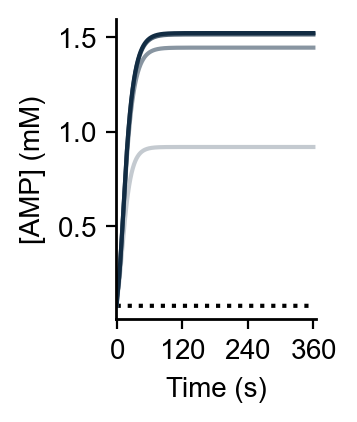

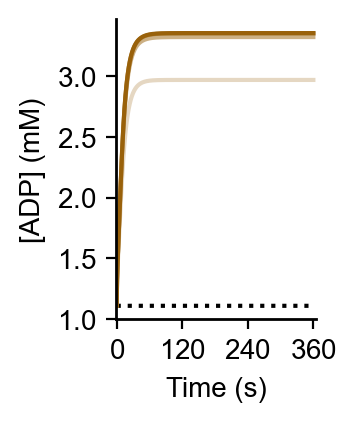

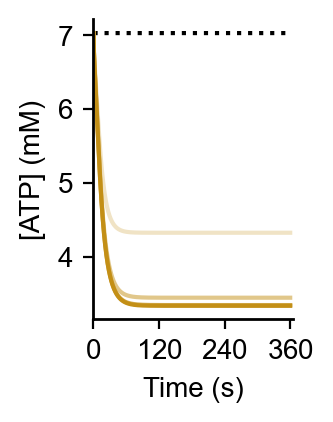

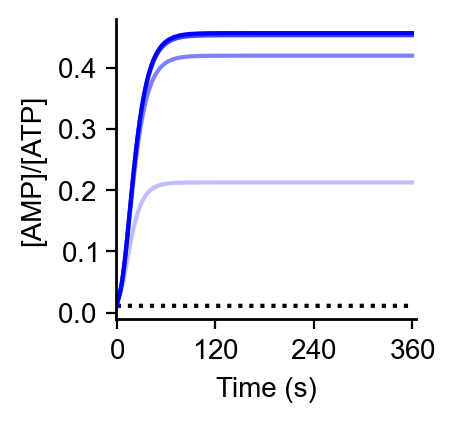

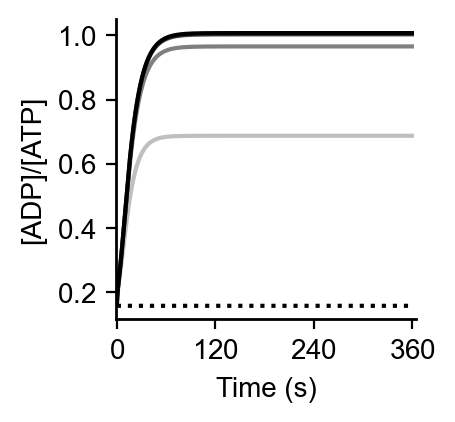

In [12]:
kGlys = jnp.array([0.5, 5e-2, 5e-3, 5e-4, 5e-5]) #, 5.0, 50.0])
sols = {}

for kGly in kGlys:
    metab_params_test = metab_params_basal_Cocci.copy()
    metab_params_test = metab_params_test.at[0].set(kGly)

    sols[str(kGly)] = dfrx.diffeqsolve(rhs_Cocci, solver, t0, t1, dt0, y0_new_Cocci, args = metab_params_test, saveat=saveat, stepsize_controller=stepsize_controller)

cmap_amp = LinearSegmentedColormap.from_list("custom_cmap_amp", ["white", colors[2]])
amp_cols = cmap_amp(np.linspace(0, 1, len(kGlys)))
cmap_adp = LinearSegmentedColormap.from_list("custom_cmap_adp", ["white", colors[3]])
adp_cols = cmap_adp(np.linspace(0, 1, len(kGlys)))
cmap_atp = LinearSegmentedColormap.from_list("custom_cmap_atp", ["white", colors[4]])
atp_cols = cmap_atp(np.linspace(0, 1, len(kGlys)))

cmap_amp_atp = LinearSegmentedColormap.from_list("custom_cmap_amp_atp", ["white", 'blue'])
amp_atp_cols = cmap_amp_atp(np.linspace(0, 1, len(kGlys)))
cmap_adp_atp = LinearSegmentedColormap.from_list("custom_cmap_adp_atp", ["white", 'black'])
adp_atp_cols = cmap_adp_atp(np.linspace(0, 1, len(kGlys)))

# plot
fig_amp, ax_amp = get_sized_fig_ax(width=1.0, height=1.5)
fig_adp, ax_adp = get_sized_fig_ax(width=1.0, height=1.5)
fig_atp, ax_atp = get_sized_fig_ax(width=1.0, height=1.5)

fig_amp_atp, ax_amp_atp = get_sized_fig_ax(width=1.5, height=1.5)
fig_adp_atp, ax_adp_atp = get_sized_fig_ax(width=1.5, height=1.5)

for i, key in enumerate(sols.keys()):
    if key == '0.5':
        lstyle = ':'
        amp_col = 'black'
        adp_col = 'black'
        atp_col = 'black'
        amp_atp_col = 'black'
        adp_atp_col = 'black'
    else:
        lstyle = '-'
        amp_col = amp_cols[i]
        adp_col = adp_cols[ i]
        atp_col = atp_cols[ i]
        amp_atp_col = amp_atp_cols[ i]
        adp_atp_col = adp_atp_cols[ i]

    ax_amp.plot(sols[key].ts, sols[key].ys[:,0], label=key, color=amp_col, linestyle = lstyle)
    ax_adp.plot(sols[key].ts, sols[key].ys[:,1], label=key, color=adp_col, linestyle = lstyle)
    ax_atp.plot(sols[key].ts, sols[key].ys[:,2], label=key, color=atp_col, linestyle = lstyle)

    ax_amp_atp.plot(sols[key].ts, sols[key].ys[:,0]/sols[key].ys[:,2], label=key, color=amp_atp_col, linestyle = lstyle)
    ax_adp_atp.plot(sols[key].ts, sols[key].ys[:,1]/sols[key].ys[:,2], label=key, color=adp_atp_col, linestyle = lstyle)
    


for ax in [ax_amp, ax_adp, ax_atp, ax_amp_atp, ax_adp_atp]:
    # ax.set_yscale('log')
    ax.set_xlim([-1, times[-1] + 5])
    ax.set_xticks([0, 120, 240, 360])
    ax.set_xlabel('Time (s)', fontsize=10)

ax_amp.set_ylabel('[AMP] (mM)', fontsize=10)
ax_adp.set_ylabel('[ADP] (mM)', fontsize=10)
ax_atp.set_ylabel('[ATP] (mM)', fontsize=10)
ax_amp_atp.set_ylabel('[AMP]/[ATP]', fontsize=10)
ax_adp_atp.set_ylabel('[ADP]/[ATP]', fontsize=10)

leg = ax_adp_atp.legend([r'Basal $(k_{Gly} = 0.5)$', r'1e-1 $\cdot k_{Gly}$', 
                         r'1e-2 $\cdot k_{Gly}$', r'1e-3 $\cdot k_{Gly}$', 
                         r'1e-4 $\cdot k_{Gly}$'], fontsize=8, bbox_to_anchor = (1.5, 1.5, 1.5, 1.5), ncol=3)
export_legend(leg, save_path + 'metab_stress_legend.pdf')
leg.remove()

fig_amp.savefig(save_path + 'metab_stress_amp_Cocci.pdf', bbox_inches='tight', transparent=True)
fig_adp.savefig(save_path + 'metab_stress_adp_Cocci.pdf', bbox_inches='tight', transparent=True)
fig_atp.savefig(save_path + 'metab_stress_atp_Cocci.pdf', bbox_inches='tight', transparent=True)
fig_amp_atp.savefig(save_path + 'metab_stress_amp_atp_Cocci.pdf', bbox_inches='tight', transparent=True)
fig_adp_atp.savefig(save_path + 'metab_stress_adp_atp_Cocci.pdf', bbox_inches='tight', transparent=True)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/3654181190.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['5e-2', '5e-3', '5e-4', '5e-5'], fontsize=8, rotation=0)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/3654181190.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklbl, fontsize=8, rotation=0)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_25433/3654181190.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_path + 'metab_stress_ratios_Cocci.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compa

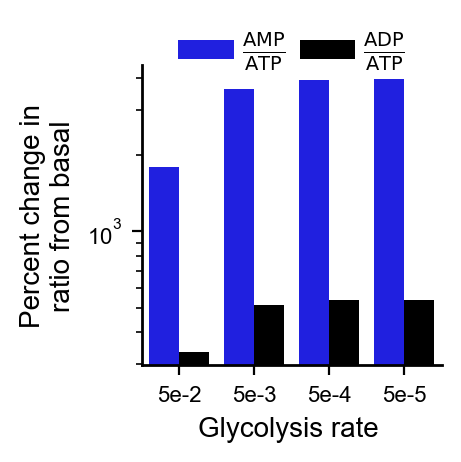

In [13]:
# plot a bar chart of the change in [AMP]/[ATP] and [ADP]/[ATP] ratios
baseline = (np.array(y0_new_Cocci[0]/y0_new_Cocci[2]), np.array(y0_new_Cocci[1]/y0_new_Cocci[2]))
ratios = {}
for key in sols.keys():
    if key == '0.5':
        pass
    else:
        ratios[key] = {'AMP_ATP':100*(np.array(sols[key].ys[-1,0]/sols[key].ys[-1,2]) - baseline[0])/baseline[0], 
                       'ADP_ATP':100*(np.array(sols[key].ys[-1,1]/sols[key].ys[-1,2]) - baseline[1])/baseline[1]}

dat = pd.DataFrame(ratios).reset_index().melt(id_vars='index', var_name='Ratio', value_name='Change (%)')

fig, ax = get_sized_fig_ax(width=1.5, height=1.5)
sns.barplot(data=dat, x='Ratio', y='Change (%)', hue='index', palette=['blue', 'black'], ax = ax)
ax.set_yscale('log')
# legend
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), fontsize=10, 
                   ncols=2,columnspacing=0.5, handletextpad=0.3)
new_labels = [r'$\frac{AMP}{ATP}$', r'$\frac{ADP}{ATP}$']
for text, new_label in zip(legend.get_texts(), new_labels):
    text.set_text(new_label)
# Remove the legend title if it exists
legend.set_title(None)

# xticklabels
ax.set_xticklabels(['5e-2', '5e-3', '5e-4', '5e-5'], fontsize=8, rotation=0)
yticklbl = ax.get_yticklabels()
ax.set_yticklabels(yticklbl, fontsize=8, rotation=0)
ax.set_xlabel('Glycolysis rate ', fontsize=10)
ax.set_ylabel('Percent change in\nratio from basal', fontsize=10)

fig.savefig(save_path + 'metab_stress_ratios_Cocci.pdf', bbox_inches='tight', transparent=True)

In [23]:
print('basal (0.5): ', np.max(sols['0.5'].ys[:,0]/sols['0.5'].ys[:,2]))
print('stressed (0.005): ', np.max(sols['0.005'].ys[:,0]/sols['0.005'].ys[:,2]))

basal (0.5):  0.011203629261843496
stressed (0.005):  0.4194784177328778
